In [40]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from scipy.stats import gaussian_kde
from scipy.spatial import cKDTree
from scipy.special import digamma
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsRegressor
import scienceplots

In [2]:
plt.style.use(["science", "notebook", "grid"])

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("running on", DEVICE)

running on cpu


In [3]:
QUICK_TRAINING = False

# set seed
SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)

# folders
DATADIR = "data"
MODELDIR = "models"
for d in [DATADIR, MODELDIR]:
    os.makedirs(d, exist_ok=True)

# define priors
PRIORS = {
    "a": [0.5, 2.0],
    "sigma": [0.05, 0.3]
}
PARAM_NAMES = list(PRIORS.keys())

# model settings
N_SUMMARY = 4
N_FILTERS = 16 # default encoder width
FILTER_LIST = [4, 8, 16, 32]

W_REG = 2.0 # weight of the regression loss
TOBS = 64
TWARMUP = 64
DT = 0.05

# training settings
if QUICK_TRAINING:
    N_TRAIN, N_TEST = 800, 400
    EPOCHS = 15
    FILTER_LIST = [4, 16]
else:
    N_TRAIN, N_TEST = 3000, 800
    EPOCHS = 60

N_MI = 1200 # number of test points used for MI estimates

## Bistable Model

The data we use are a discretized stochastic double well:
$$x_{t+1} = x_t + dt\cdot(a\cdot x_t - x_t^3) + \sigma\cdot\sqrt{dt}\cdot\varepsilon_t, \qquad \varepsilon_t \sim N(0,1)$$
with potential
$$V(x) = -a x^2 / 2 + x^4 /4$$

For $a>0$ the potential has two minima $x=\pm \sqrt{a}$, so with the same parameters the trajectory can go to the left or the right well, depending on the noise.

The two parameters to infer are $a$, that decides the separation between the two wells, and $\sigma$, which decides the trajectory jittering.

In [4]:
def generate_dataset(n_samples, stats=None):
    # draw random parameters
    a = np.random.uniform(*PRIORS["a"], n_samples)
    sigma = np.random.uniform(*PRIORS["sigma"], n_samples)

    # define noise and data samples
    eps = np.random.randn(n_samples, TWARMUP + TOBS)
    x = np.zeros(n_samples)
    X = np.zeros((n_samples, TOBS), dtype=np.float32)

    # generate samples
    for t in range(TWARMUP+TOBS):
        x = x + DT * (a * x - x**3) + sigma * np.sqrt(DT) * eps[:, t]
        if t >= TWARMUP:
            X[:, t-TWARMUP] = x
    Noise = eps[:, TWARMUP:].astype(np.float32)
    Params = np.stack([a, sigma], axis=1).astype(np.float32)

    # normalize x and parameters (noise already normalized)
    if stats is None:
        # store values to un-normalize data
        stats = {"x_mean": X.mean(), "x_std": X.std(),
                 "p_mean": Params.mean(0), "p_std": Params.std(0)}
    Xn = (X - stats["x_mean"]) / stats["x_std"]
    Pn = (Params - stats["p_mean"]) / stats["p_std"]

    return Xn, Noise, Pn, Params, stats

def get_data(n, tag, stats=None):
    # data backup so we do not regenerate data at each run
    path = os.path.join(DATADIR, f"{tag}_{n}.npz")
    if os.path.isfile(path):
        d = np.load(path, allow_pickle=True)
        st = stats if stats is not None else d["stats"].item()
        return d["X"], d["N"], d["P"], d["Praw"], st
    X, N, P, Praw, st = generate_dataset(n, stats=stats)
    np.savez(path, X=X, N=N, P=P, Praw=Praw, stats=st)
    return X, N, P, Praw, st

In [5]:
Xtr, Ntr, Ptr, Ptr_raw, stats = get_data(N_TRAIN, "train")
Xte, Nte, Pte, Pte_raw, _ = get_data(N_TEST, "test", stats=stats)

print(f"train: {Xtr.shape}\ntest: {Xte.shape}")

train: (3000, 64)
test: (800, 64)


These are 3 plots of a few trajectories to see the two wells and the different noise levels.
The dashed lines are the two wells at $x=\pm \sqrt{a}$.

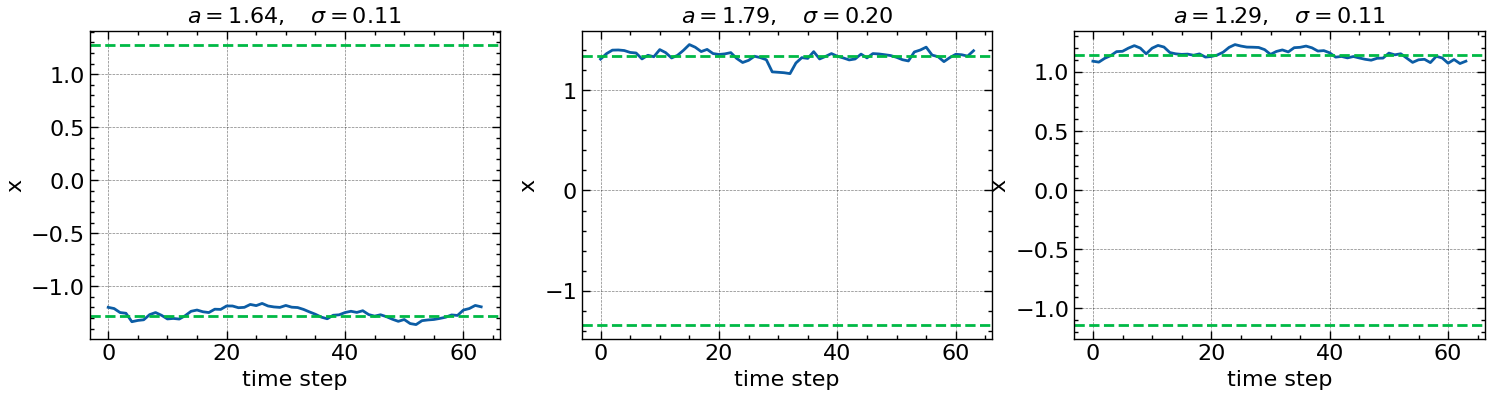

In [6]:
fig,axes = plt.subplots(1,3,figsize=(18,4))
for j in range(3):
    ax = axes[j]
    i = np.random.randint(N_TRAIN)
    x = Xtr[i] * stats["x_std"] + stats["x_mean"]
    ax.plot(x)

    # line of the corresponding two wells
    list_y = [np.sqrt(Ptr_raw[i,0]), -np.sqrt(Ptr_raw[i,0])]
    for y in list_y:
        ax.axhline(y, c="C1", ls="--")
    ax.set_title(f"$a = {Ptr_raw[i,0]:.2f},\quad \sigma = {Ptr_raw[i,1]:.2f}$")
    ax.set_xlabel("time step")
    ax.set_ylabel("x")

plt.show()

## ENCA Architecture
An autoencoder composed by:
- an encoder, a 1D CNN that compresses the series into N_SUMMARY numbers;
- a decoder, a small biLSTM that receives as input the summaries and the bare noise eps, and from that it has to rebuild the series. Since the noise is conditioned, the encoder has no reason to map it in the latent space.

In [7]:
class Encoder(nn.Module):
    def __init__(self, n_summary, n_filters=16):
        super().__init__()
        f = n_filters
        # two input channels: the series and its increments
        self.net = nn.Sequential(
            nn.Conv1d(2, f, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv1d(f, f, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(f, 2*f, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv1d(2*f, n_summary, kernel_size=3, padding=1),
        )
        # we pool mean and std, so the head sees both -> 2*n_summary in
        self.head = nn.Linear(2 * n_summary, n_summary)

    def forward(self, x):
        dx = torch.diff(x, dim=1, prepend=x[:, :1])
        h = torch.stack([x, dx], dim=1)        # (batch, 2, T)
        h = self.net(h)
        feat = torch.cat([h.mean(-1), h.std(-1)], dim=-1)
        return self.head(feat)


class Decoder(nn.Module):
    def __init__(self, n_summary):
        super().__init__()
        self.lstm = nn.LSTM(input_size=n_summary + 1, hidden_size=16,
                            num_layers=2, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(32, 1)

    def forward(self, s, noise):
        # tile the summaries along time and stick the noise next to them
        s_tiled = s.unsqueeze(1).expand(-1, noise.shape[1], -1)
        inp = torch.cat([s_tiled, noise.unsqueeze(2)], dim=-1)
        out, _ = self.lstm(inp)
        return self.fc(out).squeeze(-1)


class ENCA(nn.Module):
    def __init__(self, n_summary, n_filters=16):
        super().__init__()
        self.encoder = Encoder(n_summary, n_filters=n_filters)
        self.decoder = Decoder(n_summary)

    def forward(self, x, noise):
        s = self.encoder(x)
        x_hat = self.decoder(s, noise)
        return s, x_hat

In [8]:
def train_enca(X, Noise, Params, n_filters=16, epochs=60, batch_size=128,
               lr=1e-3, verbose=True):
    # initialize the training by specifying the hyperparameters
    n_params = Params.shape[1]
    loader = DataLoader(TensorDataset(torch.tensor(X), torch.tensor(Noise), torch.tensor(Params)),
                        batch_size=batch_size, shuffle=True)

    model = ENCA(N_SUMMARY, n_filters=n_filters).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.ExponentialLR(opt, gamma=0.99)
    mse = nn.MSELoss()

    # start training
    model.train()
    for epoch in range(epochs):
        tot = 0.0
        for xb, nb, pb in loader:
            xb, nb, pb = xb.to(DEVICE), nb.to(DEVICE), pb.to(DEVICE)
            s, x_hat = model(xb, nb)
            # reconstruction + parameter regression
            loss = mse(x_hat, xb) + W_REG * mse(s[:, :n_params], pb)

            opt.zero_grad()
            loss.backward()
            opt.step()
            tot += loss.item()
        sched.step()
        if verbose and (epoch + 1) % 20 == 0:
            print(f"  epoch {epoch+1:3d}   loss {tot/len(loader):.4f}")
    return model


def get_summaries(model, X, Noise):
    # summaries S and reconstruction for a whole dataset
    model.eval()
    with torch.no_grad():
        s, x_hat = model(torch.tensor(X).to(DEVICE), torch.tensor(Noise).to(DEVICE))
    return s.cpu().numpy(), x_hat.cpu().numpy()


def get_enca(X, N, P, n_filters, epochs, tag="main"):
    # start the experiment
    path = os.path.join(MODELDIR, f"enca_{tag}_f{n_filters}_s{N_SUMMARY}_n{len(X)}.pt")
    model = ENCA(N_SUMMARY, n_filters=n_filters).to(DEVICE)
    
    if os.path.isfile(path):
        # load model
        model.load_state_dict(torch.load(path, map_location=DEVICE))
        model.eval()
        return model
    else:
        # train model and then save it
        model = train_enca(X, N, P, n_filters=n_filters, epochs=epochs)
        torch.save(model.state_dict(), path)
        return model

In [9]:
print("training the main ENCA...")
model = get_enca(Xtr, Ntr, Ptr, N_FILTERS, EPOCHS)

S_te, Xhat_te = get_summaries(model, Xte, Nte)
recon_mse = float(np.mean((Xhat_te - Xte) ** 2))
print("test reconstruction MSE:", round(recon_mse, 4))

training the main ENCA...
test reconstruction MSE: 0.0081


A few reconstructions:

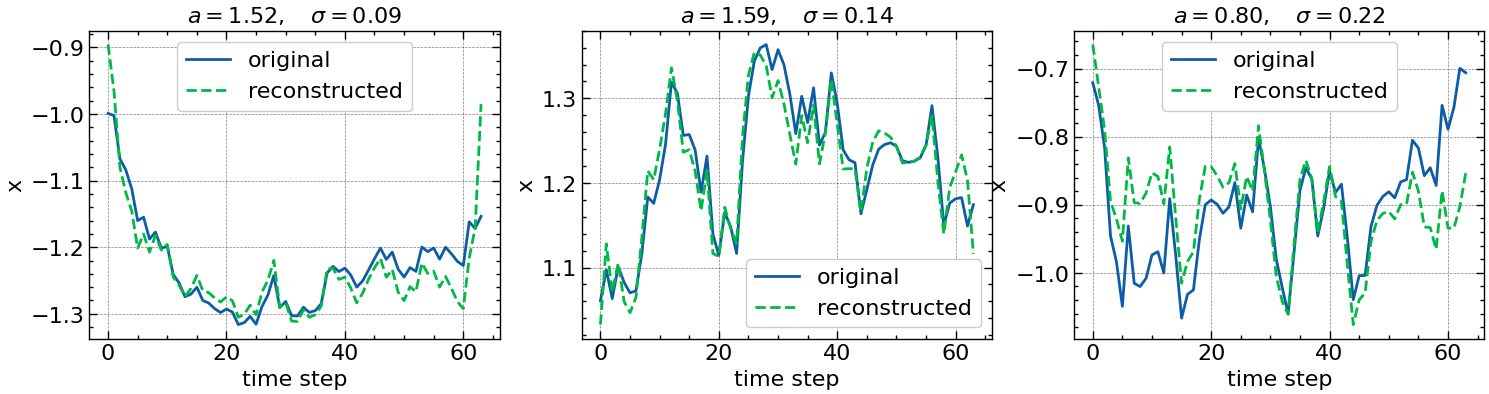

In [10]:
fig,axes = plt.subplots(1,3,figsize=(18,4))
for j in range(3):
    ax = axes[j]
    i = np.random.randint(N_TEST)
    x = Xte[i] * stats["x_std"] + stats["x_mean"]
    xh = Xhat_te[i] * stats["x_std"] + stats["x_mean"]
    
    ax.plot(x, label="original")
    ax.plot(xh, label="reconstructed", ls="--")

    # line of the corresponding two wells
    ax.set_title(f"$a = {Pte_raw[i,0]:.2f},\quad \sigma = {Pte_raw[i,1]:.2f}$")
    ax.set_xlabel("time step")
    ax.set_ylabel("x")
    ax.legend()

plt.show()

Check whether the two parameters were retrieved correctly by the summaries:

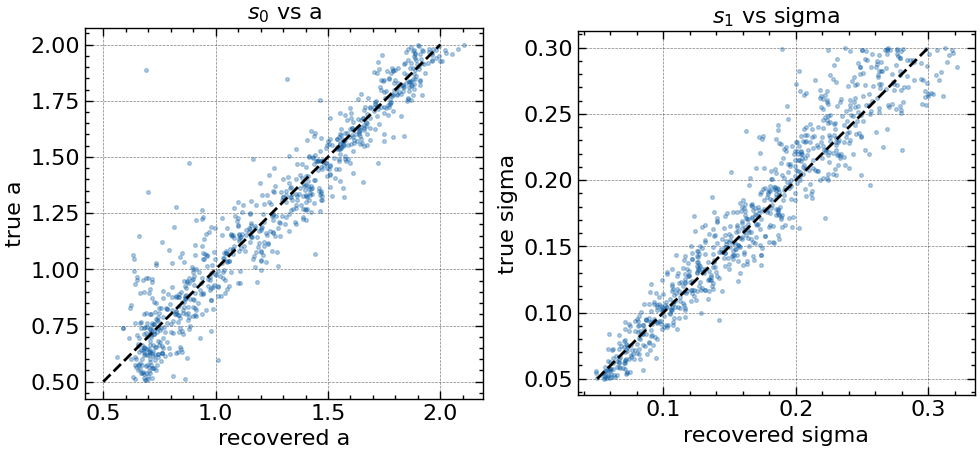

In [11]:
# scatterplot
fig,axes = plt.subplots(1,2,figsize=(10,5))
for j,name in enumerate(PARAM_NAMES):
    ax = axes[j]
    # de-normalize parameters to physical units
    s_real = S_te[:, j] * stats["p_std"][j] + stats["p_mean"][j]
    low, high = PRIORS[name]

    ax.scatter(s_real, Pte_raw[:,j], s=7, alpha=0.3)
    ax.plot([low,high], [low,high], c="k", ls="--")
    ax.set_title(f"$s_{j}$ vs {name}")
    ax.set_xlabel(f"recovered {name}")
    ax.set_ylabel(f"true {name}")
    ax.set_aspect("equal")

plt.tight_layout()
plt.show()

## Mutual Information Estimators
$$I[X:Y] = \int \int p(x,y) \log \left( \frac{p(x,y)}{p(x)\,p(y)} \right ) dx dy$$
We need mutual information between continuous variables but we don't know the densities. To solve this problem, we use thre methods (binning, KDE, KSG) to generate the probability densities.

### 1. Classic binning
Generate the histogram from the scatterplot and pretend it it's exactly the probability density. From there, we use that information to calculate the Shannon entropy for this formula:
$$I[X:Y] = H[X] + H[Y] - H[X,Y]$$
to calculate MI.

In [37]:
def _as2d(a):
    # convert a list of points to an array and reshape it in 2D
    a = np.asarray(a, dtype=np.float64)
    if a.ndim == 1:
        a = a.reshape(-1,1)
    
    return a

def entropy_binning(x, bins=20):
    # separate in bins
    counts, _ = np.histogramdd(x, bins=bins)
    # normalize binning count
    p = counts / counts.sum()
    p = p[p>0]
    
    # calculate Shannon entropy
    h = float(-np.sum(p * np.log(p)))
    
    return h

def mi_binning(x, y, bins=20):
    # preprocess the arrays x, y, xy
    x, y = _as2d(x), _as2d(y)
    xy = np.concatenate([x, y], axis=1)

    # calculate MI
    mi = entropy_binning(x,bins) + entropy_binning(y,bins) - entropy_binning(xy,bins)

    return mi

### 2. Kernel Density Estimation (KDE)
Here we use the fact that, given the probability densities from KDE, the MI is just the average on the true distribution. Since our data are samples taken from the true distribution, we can replace the integral with the average on our data:
$$I[X:Y] = \left<\ \log\, p(x,y) - \log\, p(x) - \log\, p(y)  \ \right>$$

In [38]:
def mi_kde(x, y):
    # preprocess the arrays x, y, xy
    x, y = _as2d(x), _as2d(y)
    xy = np.concatenate([x, y], axis=1)

    # calculate log probabilites from the KDE
    log_px = gaussian_kde(x.T).logpdf(x.T)
    log_py = gaussian_kde(y.T).logpdf(y.T)
    log_pxy = gaussian_kde(xy.T).logpdf(xy.T)

    # calculate MI
    mi = float(np.mean(log_pxy - log_px - log_py))

    return mi

### 3. Kraskov (KSG)
Instead of relying on probability densities we have an idea of the information just by checking the points' neighbors distance. A point that has many neighbors in a small region of space hints to a dependence between the two variables.

For each point we create the smallest squared boundary that contains for that point $k$ neighbors along X and along Y. After defining that region of space, we look at the strip that continue indefinetly along the Y direction, meaning that we look at the rectangular region that has as the width the same width of the squared region from before (the one that contained $k$ neighbors along the x axis) and the height of the rectangle is infinite.
X and Y are related if the total number of points inside that rectangular strip is $n_x\cdot n_y \approx k$. If the result is $\gg k$ then they're unrelated.

We could express the mutual information using this formula:
$$\hat{I}[X:Y] = \log \left( \frac{k\cdot N}{n_x\cdot n_y} \right )$$
but the logarithm would add a bias term that is easily removed using instead the digamma function $\psi$. So, the formula used to calculate MI is:
$$\hat{I}[X:Y] = \psi(k) + \psi(N) - \left< \psi(n_x +1)+ \psi(n_y +1) \right >$$

In [41]:
def mi_kraskov(x, y, k=5):
    n = len(x)
    
    # preprocess the arrays x, y, xy
    x, y = _as2d(x), _as2d(y)
    xy = np.concatenate([x, y], axis=1)

    # find the box size (eps) for each point
    dist, _ = cKDTree(xy).query(xy, k=k + 1, p=np.inf) # k=k+1 because the first element found is the point itself
    eps = dist[:, k]

    # count how many points there are inside the strip
    tree_x, tree_y = [cKDTree(v) for v in [x,y]]
    nx, ny = [np.zeros(n) for _ in range(2)]
    for i in range(n):
        nx[i] = len(tree_x.query_ball_point(x[i], eps[i]-1e-12, p=np.inf)) - 1
        ny[i] = len(tree_y.query_ball_point(y[i], eps[i]-1e-12, p=np.inf)) - 1

    # calculate MI
    mi = float(digamma(k) + digamma(n) - np.mean(digamma(nx + 1) + digamma(ny + 1)))

    return mi    

## Calculate Mutual Information
Here we actually test whether the summaries actually keeps all the informations about the parameters. So, we want:
- $\text{MI}(X,\theta) \approx \text{MI}(s,\theta) \approx H(\theta)$, meaning that the summary statistics have extracted all the information about the parameters inside data.
- $\text{MI}(X,\varepsilon) \approx \text{MI}(s,\varepsilon) \approx 0$, meaning that the summary statistics are enough to reconstruct parameters.

First, we compare the three methods where they are all well defined (1D vs 1D).

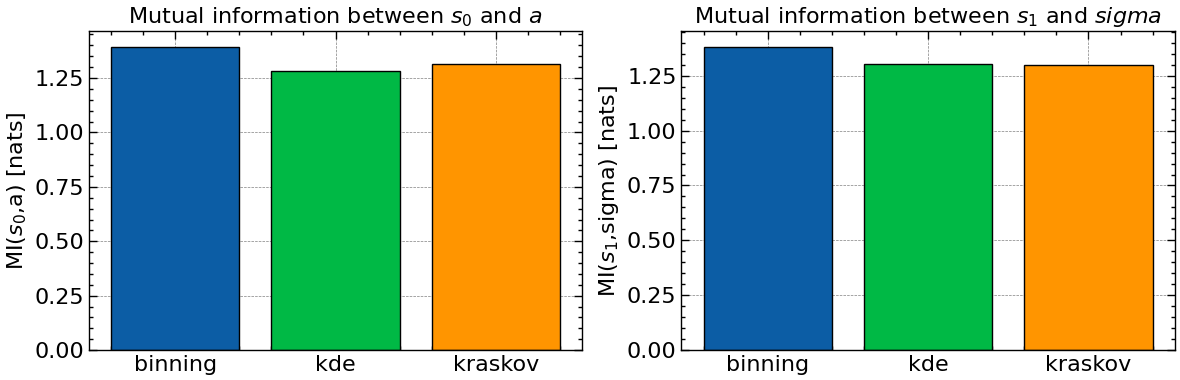

In [70]:
# pick random summaries and parameters from the test set
idx = np.random.choice(N_TEST, min(N_MI, N_TEST), replace=False)
S = S_te[idx]
Params = Pte_raw[idx]

fig,axes = plt.subplots(1,2,figsize=(12,4))
# compare the parameters and summaries
for i in range(2):
    ax = axes[i]
    x = S[:, i:i+1]
    y = Params[:, i:i+1]
    
    # calculate MI with the 3 methods
    results = {
        "binning": mi_binning(x, y, bins=24),
        "kde": mi_kde(x, y),
        "kraskov": mi_kraskov(x, y, k=5)
    }
    
    ax.bar(np.arange(3), list(results.values()), color=[f"C{j}" for j in range(3)], ec="k")
    ax.set_title(f"Mutual information between $s_{i}$ and ${PARAM_NAMES[i]}$")
    ax.set_xticks(np.arange(3), list(results.keys()))
    ax.set_ylabel(f"MI($s_{i}$,{PARAM_NAMES[i]}) [nats]")
fig.tight_layout()
plt.show()

We can see that they all give similar numbers, so we have reliable estimators.

To calculate the 4 MI, we have to deal with a couple of problems:
- $\text{MI}(X,\varepsilon) = h(X)-h(X|\varepsilon)$. In this case, $h(X|\varepsilon)=-\infty$, because $\varepsilon$ determins X completely. $\implies \text{MI}(X,\varepsilon) = +\infty$
- We are using samples that lives in 64 dimensions (TOBS). The three MI estimators works by checking how clustered the points are, and in 64D the distances blow up so much that each sample has no neighbors. Even in the 4D summary we have this kind of problem because only one of the components carries information about $\sigma$, the other three just increase the distances of the points, giving a worse result in calculating MI.

To solve this problem, we follow these steps:
1. take 800 test points and for each of them we guess the true $a$ from $s$. The guessing is done using a k-NN regressor, which finds the 15 points with the most similar $s$, and average their $a$.
2. this creates 800 tuples of 2 numbers: (guess, true value).
3. run Kraskov on these two columns, and this is the answer.

In [83]:
def sufficient_features(X):
    # near-sufficient summary of a trajectory: where it sits (a) and how it jumps (sigma)
    # this is our replacement for X
    x = X * stats["x_std"] + stats["x_mean"]
    dx = np.diff(x, axis=1)
    phi = np.stack([x.mean(1), (x**2).mean(1), np.abs(x.mean(1)),
                    dx.std(1), np.abs(dx).mean(1)], axis=1)
    
    return phi

def decodable_mi(R, target, k=5, n_neighbors=15, folds=5):
    R = _as2d(R)
    Rs = (R - R.mean(0)) / (R.std(0) + 1e-9)
    n = len(target)
    pred = np.empty(n)
    order = np.random.permutation(n)
    for fold in np.array_split(order, folds):
        train = np.setdiff1d(order, fold)
        knn = KNeighborsRegressor(n_neighbors).fit(Rs[train], target[train])
        pred[fold] = knn.predict(Rs[fold])
    ss_res = np.sum((target - pred) ** 2)
    ss_tot = np.sum((target - target.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot
    return mi_kraskov(pred, target, k=k), r2

In [84]:
# pick random test samples
idx = np.random.choice(N_TEST, min(N_MI, N_TEST), replace=False)
# find the near-sufficient summaries
phiX = sufficient_features(Xte[idx])
# sum noise and project the accumulated sums on 6D by PCA
eps_pca = PCA(6).fit_transform(np.cumsum(Nte[idx], axis=1))

# 
mi_data, mi_summ = {}, {}
for j, name in enumerate(PARAM_NAMES):
    mi_data[name] = decodable_mi(phiX, Pte_raw[idx, j])[0]
    mi_summ[name] = decodable_mi(S_te[idx], Pte_raw[idx, j])[0]
mi_data["eps"] = mi_kraskov(phiX, eps_pca)
mi_summ["eps"] = mi_kraskov(S_te[idx], eps_pca)

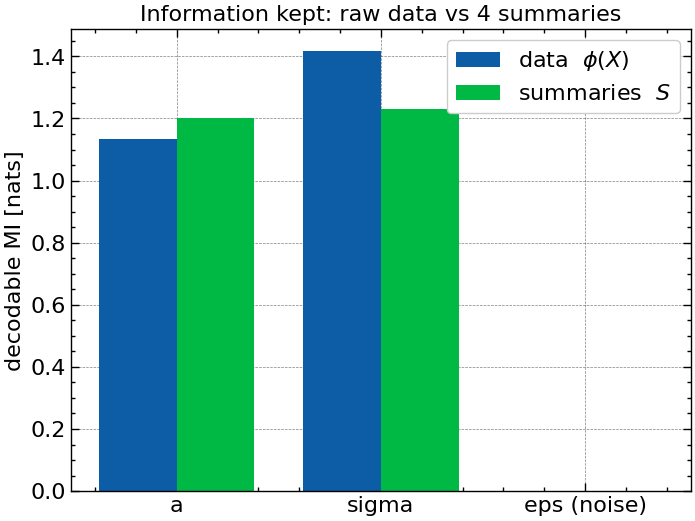

In [86]:
groups = ["a", "sigma", "eps"]
data_vals = [mi_data[g] for g in groups]
summ_vals = [mi_summ[g] for g in groups]
xpos = np.arange(len(groups))
w = 0.38

fig,ax = plt.subplots()
ax.bar(xpos - w/2, data_vals, width=w, label="data  $\\phi(X)$")
ax.bar(xpos + w/2, summ_vals, width=w, label="summaries  $S$")
ax.legend()
ax.set_title("Information kept: raw data vs 4 summaries")
ax.set_ylabel("decodable MI [nats]")
ax.set_xticks(xpos, ["a", "sigma", "eps (noise)"])
plt.show()